# <span style="color:purple; font-weight:bold; text-decoration:underline;">CESM2.1 Large Ensemble East Asian Sulfate AOD Timeseries </span>

### <span style="color:purple"> Imports

In [1]:
import xarray as xr

### <span style="color:purple"> Area file and region masks

In [2]:
area = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/area_files/AREA.nc')
East_Asia_mask = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/masks/East_Asia/East_Asia_Mask.nc')

### <span style="color:purple"> Selecting East Asia Sulfate AOD

In [6]:
AODSO4dn = xr.open_dataset("cesm2.1_BHIST_1850-2014_data/b.e21.BHIST.f09_g17.CMIP6-historical.003.cam.h0.AODSO4dn.185001-201412.nc")["AODSO4dn"]
# Aerosol optical depth 550 nm from SO4, day night

AODSO4dn_East_Asia = AODSO4dn.where(East_Asia_mask).weighted(area).mean(("lat", "lon"))

### <span style="color:purple"> Sampling: February, May, August, and November

In [4]:
months = [3, 6, 9, 12]

months_AODSO4dn_East_Asia = [AODSO4dn_East_Asia.where(AODSO4dn_East_Asia.time.dt.month == m, drop=True) for m in months]
# Time series of AODSO4 over NPAC

### <span style="color:purple"> Plotting East Asian Sulfate AOD 'Seasonal' Timeseries

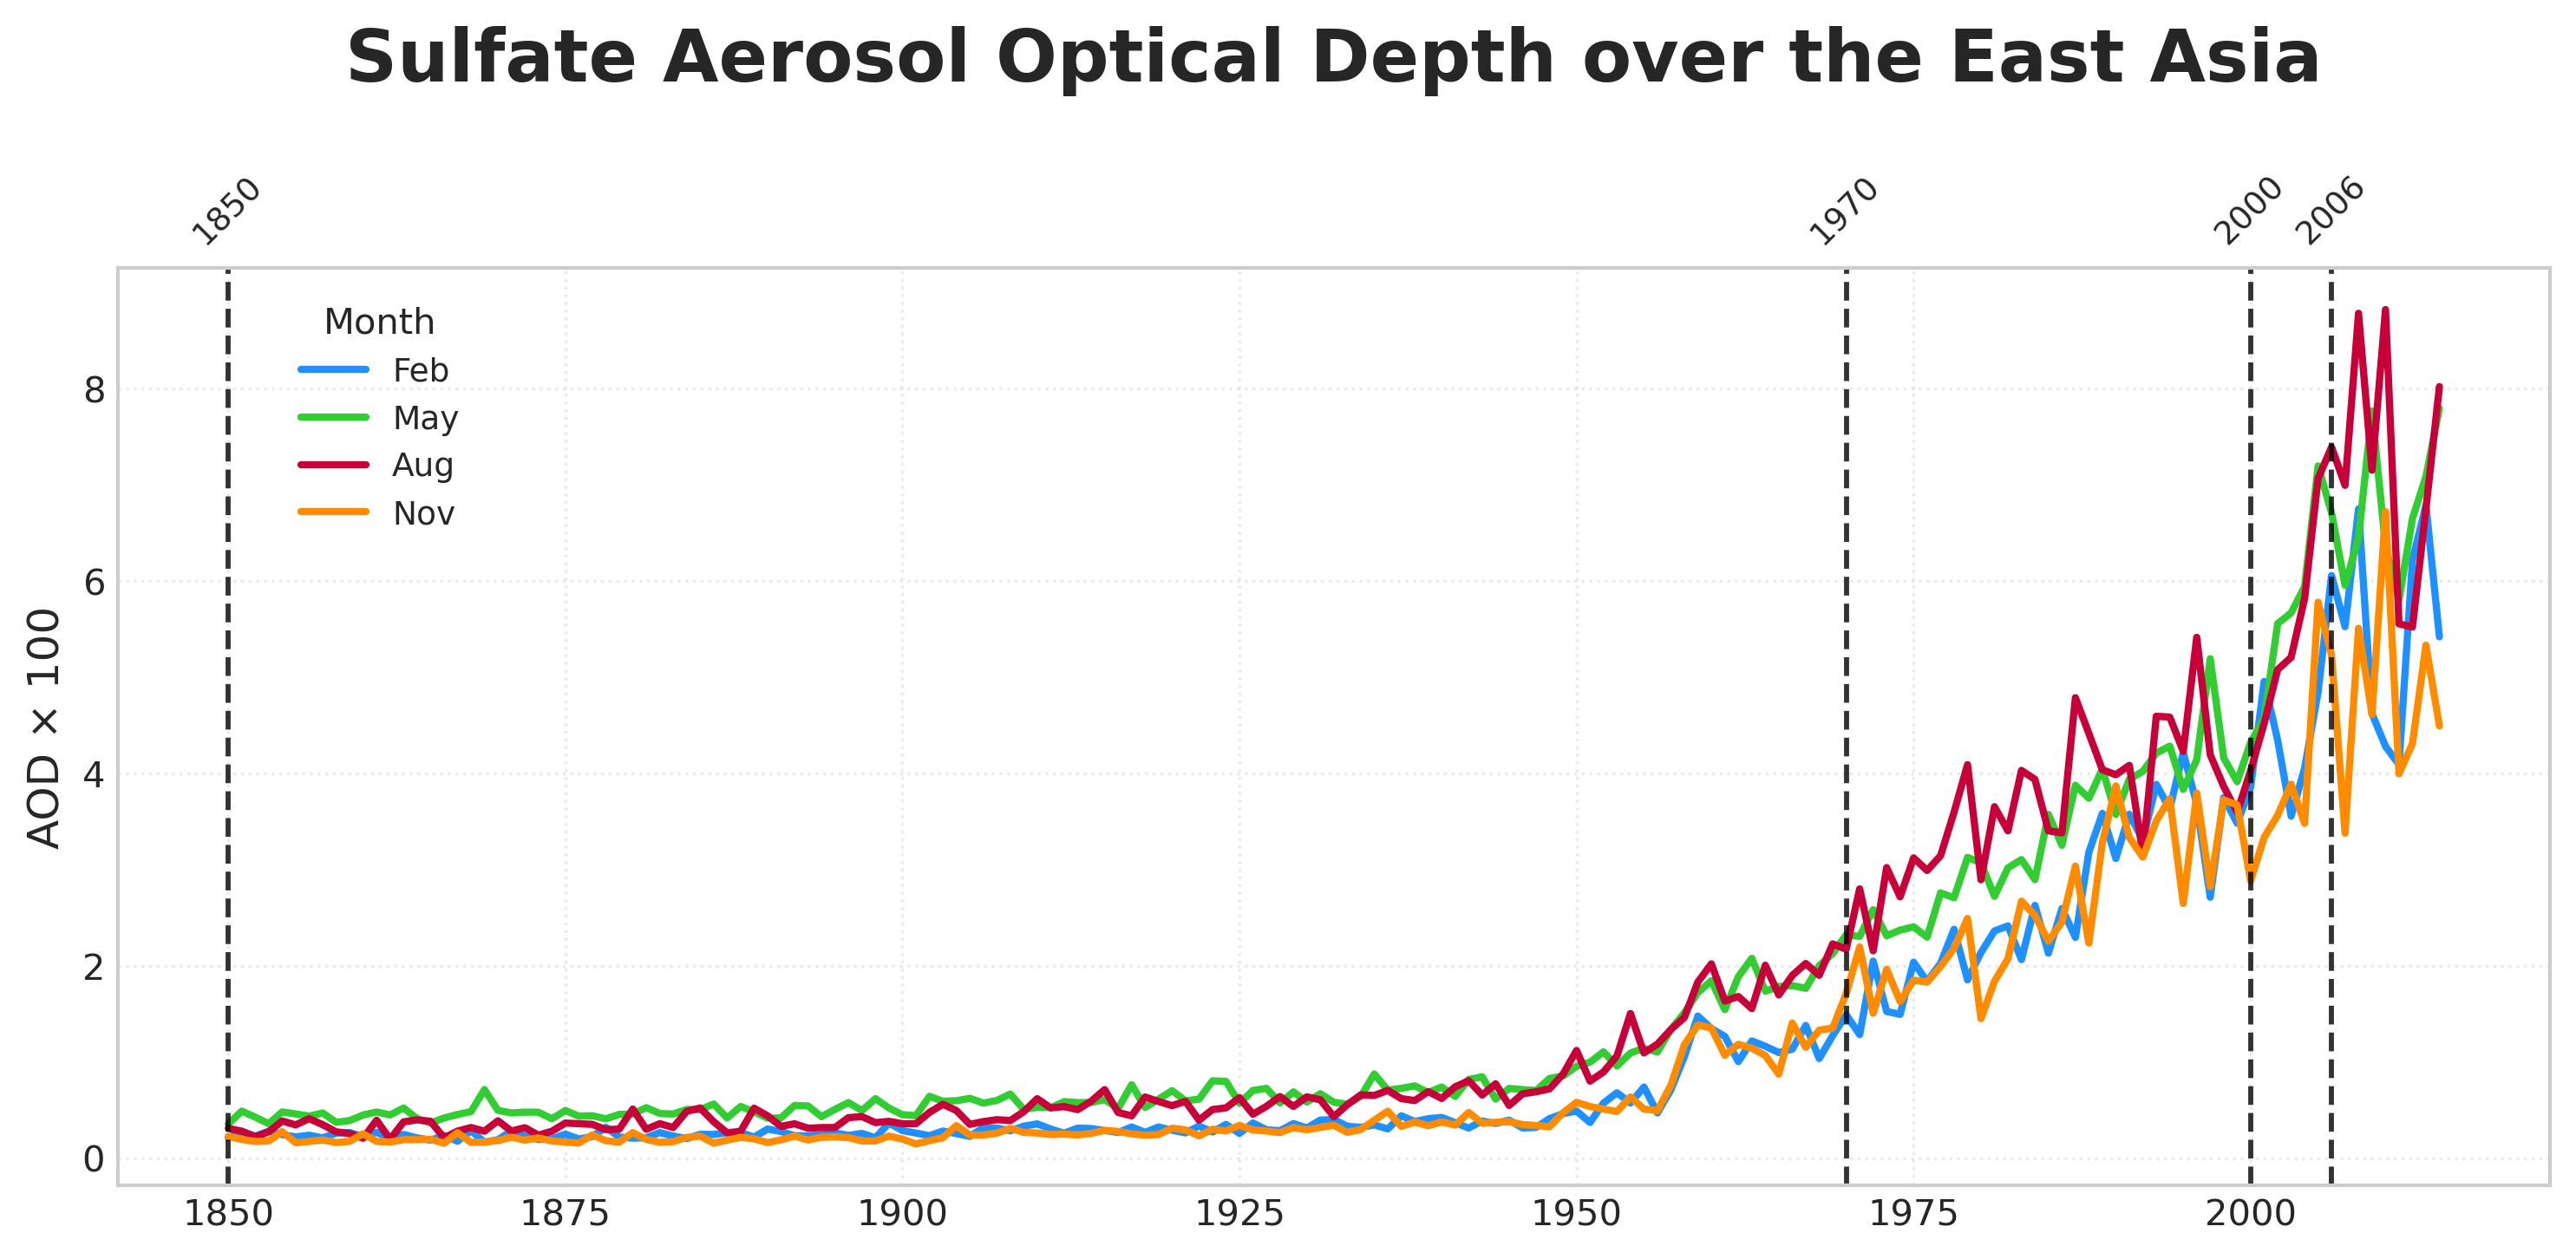

In [5]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Global style
# ---------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'legend.frameon': False, 'lines.linewidth': 2, 'axes.titleweight': 'bold'})

# ---------------------------------------------------------
# Inputs
# ---------------------------------------------------------
labels = ['Feb', 'May', 'Aug', 'Nov']
label_to_color = {'Feb': "#1E90FF", 'May': "#32CD32", 'Aug': "#C70039", 'Nov': "#FF8C00"}
highlight_years = [1850, 1970, 2000, 2006]

# Sulfur conversion constants
seconds_per_year = 60 * 60 * 24 * 365
Kg_to_Tg = 1e-9
S_SO4_ratio = 32.065 / 115.107
multiplier = seconds_per_year * Kg_to_Tg * S_SO4_ratio

# ---------------------------------------------------------
# Create figure
# ---------------------------------------------------------
fig, axs = plt.subplots(1, 1, figsize=(10, 5), dpi=300, sharex=True)

# =========================================================
# RIGHT PANEL: East Asia Sulfate AOD
# =========================================================
for arr, label in zip(months_AODSO4dn_East_Asia, labels):
    axs.plot(arr.time.dt.year, arr * 100, label=label, color=label_to_color[label])

axs.set_ylabel("AOD × 100", fontsize=12)
axs.grid(linestyle=':', alpha=0.4)

# --- Vertical timeline markers ---
for year in highlight_years:
    axs.axvline(year, linestyle='--', color='black', linewidth=1.4, alpha=0.8)


# -------------------------
# YEAR LABELS
# -------------------------

# Left panel
ymax0 = axs.get_ylim()[1]
for year in highlight_years:
    y_offset = 1.02
    axs.text(year, ymax0 * y_offset, str(year), ha='center', va='bottom', fontsize=9, rotation=45)

# =========================================================
# TITLES ABOVE EVERYTHING
# =========================================================
axs.set_title("Sulfate Aerosol Optical Depth over the East Asia",fontsize=20, y=1.18)

# ---------------------------------------------------------
# Legends
# ---------------------------------------------------------
axs.legend(title="Month", loc=(0.07, 0.7), fontsize=9)

# ---------------------------------------------------------
# Layout fixes
# ---------------------------------------------------------
plt.tight_layout()
plt.savefig('/glade/u/home/jzweifel/jupyter_workspaces/Masters_paper_analysis/notebooks/saved_figures_pngs/Figure_S1.png')

plt.show()